Quantum Circuit for sending the 4-bit message '1001':


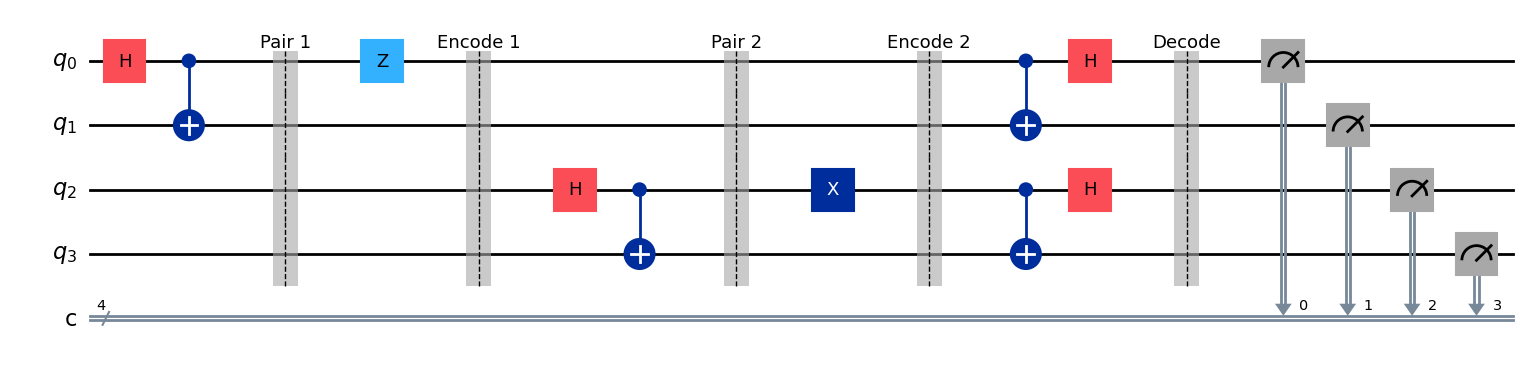


Simulation Results (Raw): {'1001': 1024}
The message Bob received is '1001', which matches the message sent.


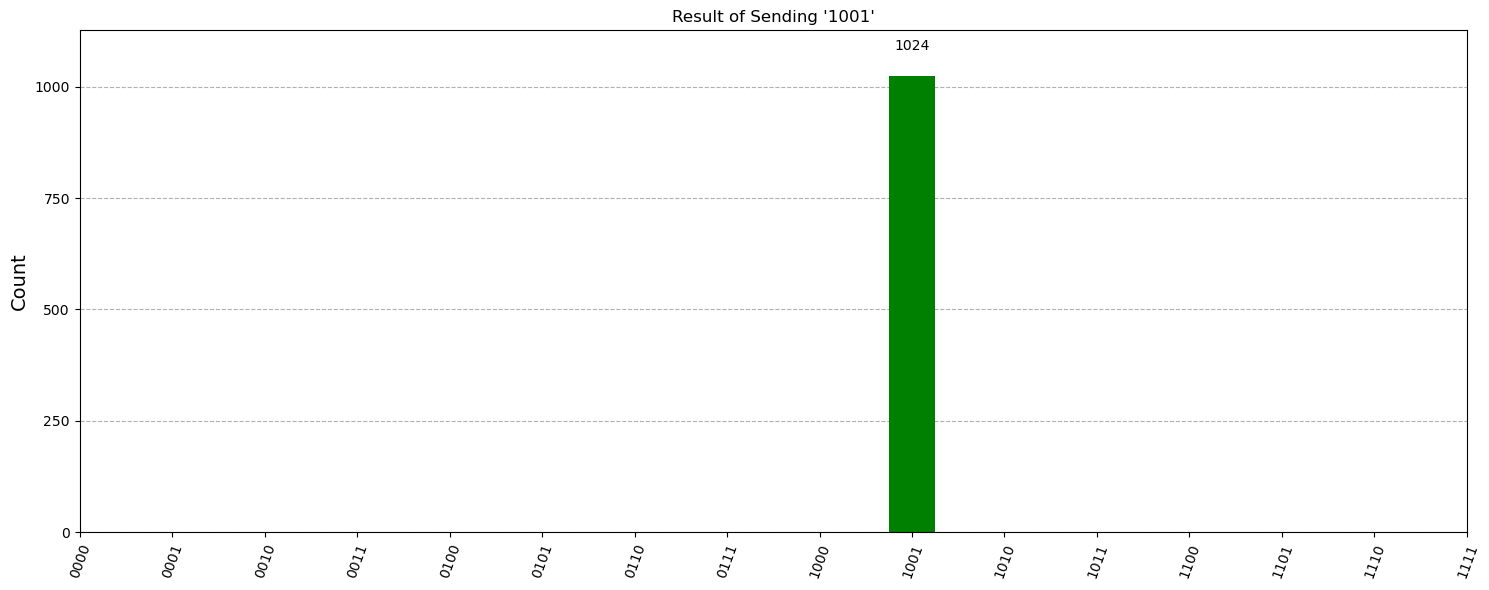

In [7]:
#
# --- ENTIRE CODE FOR 4-BIT SUPERDENSE CODING (SENDING '1001') ---
#

# Step 1: Import all the necessary components from Qiskit
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.compiler import transpile
from qiskit.visualization import plot_histogram
from IPython.display import display

# --- Define the 4-Bit Message and Create the Circuit ---

# We will send '10' on the first pair and '01' on the second pair
message_to_send = '1001'

# We need 4 qubits and 4 classical bits
qc = QuantumCircuit(4, 4)

# --- First Pair (to send '10') ---
# q[0] is Alice's first qubit, q[1] is Bob's first qubit
qc.h(0)
qc.cx(0, 1)
qc.barrier(label="Pair 1")

# Alice encodes '10' onto q[0]
# Left bit '1' -> Z gate
# Right bit '0' -> Do nothing
qc.z(0)
qc.barrier(label="Encode 1")

# --- Second Pair (to send '01') ---
# q[2] is Alice's second qubit, q[3] is Bob's second qubit
qc.h(2)
qc.cx(2, 3)
qc.barrier(label="Pair 2")

# Alice encodes '01' onto q[2]
# Left bit '0' -> Do nothing
# Right bit '1' -> X gate
qc.x(2)
qc.barrier(label="Encode 2")

# --- Bob Decodes Both Pairs ---
# Bob decodes the first pair
qc.cx(0, 1)
qc.h(0)

# Bob decodes the second pair
qc.cx(2, 3)
qc.h(2)
qc.barrier(label="Decode")

# --- Bob Measures All Qubits ---
# We measure in order to match the message '1001'
# The final string will be c3c2c1c0
qc.measure([0, 1, 2, 3], [0, 1, 2, 3])
# Qiskit's ordering means:
# q[0] -> c[0] (will be '1')
# q[1] -> c[1] (will be '0')
# q[2] -> c[2] (will be '0')
# q[3] -> c[3] (will be '1')
# The result string will be c[3]c[2]c[1]c[0] -> '1001'


# --- Visualize the Circuit ---
print(f"Quantum Circuit for sending the 4-bit message '{message_to_send}':")
display(qc.draw('mpl'))


# --- Simulate the Circuit ---
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(compiled_circuit)


# --- Display the Results ---

# Define all 16 possible 4-bit outcomes
all_possible_outcomes = [f'{i:04b}' for i in range(16)]

# Create a new dictionary with all outcomes set to 0, then update it
full_counts = {outcome: 0 for outcome in all_possible_outcomes}
full_counts.update(counts)

print("\nSimulation Results (Raw):", counts)
print(f"The message Bob received is '{list(counts.keys())[0]}', which matches the message sent.")

# Plot the new, complete dictionary 📊
# This will show all 16 possibilities, but only '1001' will have a bar.
histogram = plot_histogram(full_counts,
                           figsize=(15, 6),  # Make the plot wider
                           color='green',
                           title=f"Result of Sending '{message_to_send}'")
display(histogram)